# Brain-as-LLM Local Linearization Experiment

**Goal:** test whether human intracranial neural population dynamics can be treated, locally, like hidden-state dynamics in an LLM:

$$\hat{x}_{t+\Delta} = A\,x_t + b + \hat{w}_t$$

| LLM | Brain |
|---|---|
| hidden state $h[l,t]$ | population state $x[l,t]$ |
| layer $l$ | anatomical module (temporal cortex → entorhinal → hippocampus) |
| hidden-state dimension | electrode **channel** (never "neuron") |
| token index | 20-ms time bin |

**Story:** locally linearizable → finite temporal prediction horizon → degradation under state shift (placebo → scopolamine OOD).

Full specification: [ANALYSIS_SPEC.md](ANALYSIS_SPEC.md)

**Guardrails (from spec):**
- Fit dynamics **within patient** only; aggregate statistics across patients (patient = inferential unit).
- Split by **whole trials**, never individual time points; all preprocessing/hyperparameters from training data only.
- Residual model $\hat{w}_t = g(x_t)$ trained on **training residuals** — never add back test residuals.
- OOD evaluation uses the **frozen** model (same $A$, $b$, $g$, normalization).
- Report negative results honestly (spec §28).

## Dataset: Basu et al., *Nature BME* 2023 (closed-loop cognitive control)

**Paper:** "Closed-loop enhancement and neural decoding of cognitive control in humans" (doi:10.1038/s41551-021-00804-y) — [StimPaper.pdf](StimPaper.pdf).

Actual dataset properties (these override the spec's placeholder assumptions):

| Spec assumption | Actual dataset |
|---|---|
| Memory encoding task | **MSIT** conflict task, trials aligned to image onset |
| Placebo vs scopolamine | **Stimulation state**: NS1 (no-stim blocks) vs NS2 (non-stim trials in stim blocks) vs stimulated trials (130 Hz internal-capsule/striatal stim, 600 ms at image onset, 2–4 mA) |
| 1000 Hz native | Recorded 2 kHz → **decimated to 1000 Hz**, bipolar re-referenced, 60 Hz + harmonics removed, IED channels rejected |
| Temporal ctx → entorhinal → hippocampus | 16 regions incl. **PFC subdivisions, cingulate, OFC, temporal, insula, amygdala, hippocampus, NAcc, caudate** — layer hierarchy to be redefined on actual coverage |
| −500..+1500 ms epoch | Paper analyzes 0.1–1.4 s post-image (decision period); baseline −0.5..0 s. Trials cut with 2 s buffers |
| Bands 2–4…32–64 Hz | Paper bands: 4–8, 8–15, 15–30, 30–55, 65–110, 135–200 Hz (Morlet, 10 ms steps; high gamma split around the 130 Hz stim frequency) |

**OOD design (adapted):** train on **NS1** trials → test-ID: held-out NS1 → test-OOD: **NS2** (behavioral/physiological state shift without stim artifact). Stimulated trials are a stronger shift but artifact-contaminated — treat separately and exclude the 600-ms stim window or use post-stim segments.

**Files:**
- `Behavior_Stim_Subjects.mat` — 3224 trials, 9 subjects (P8–P15, P17): `subject, blockNum, trialNum, interference` (conflict 0/1), `responseTimes, responseCorrect, StimAny` (0/1), `trialStim`/`blockStim` (site labels: None, L/R DS, L/R VS, L Mid, CL variants).
- `BIPOLFieldTripFormat_AlignedToImagePresent_P12_Stim1.mat` — FieldTrip-format bipolar LFP epochs aligned to image onset, patient P12, stim session 1 (MATLAB v7.3/HDF5, ~2.7 GB; per-patient files expected).


## 0. Configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Paths (DATA_DIR to be pointed at the provided data folder) ----
HERE = Path.cwd() if (Path.cwd() / "ANALYSIS_SPEC.md").exists() else Path("NeuroAnalysis")
DATA_DIR = HERE / "data"          # <- point to the provided data folder
RESULTS_DIR = HERE / "results"
PRED_DIR = HERE / "predictions"
FIG_DIR = HERE / "figures"
for d in (RESULTS_DIR, PRED_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- Signal parameters (spec §2, §4, §5) ----
FS = 1000                          # native sampling rate (Hz)
EPOCH_MS = (-500, 1500)            # baseline: -500..0, encoding: 0..1500
BANDS = {
    "slow_theta": (2, 4),
    "theta": (4, 8),
    "alpha": (8, 16),
    "beta": (16, 32),
    "gamma": (32, 64),
}
PRIMARY_BAND = "theta"
TOKEN_STRIDE_MS = 20               # brain "token" spacing
CAUSAL_WINDOW_MS = 40              # x(t) = mean power over [t-40ms, t] (no future leakage)

# ---- Horizons (spec §6) ----
PRIMARY_HORIZON_MS = 20
HORIZONS_MS = [10, 20, 50, 100, 200]

# ---- Splits (spec §8): by whole trials ----
SPLIT_FRACS = (0.6, 0.2, 0.2)      # train / val / test
RANDOM_SEED = 0

# ---- Anatomical layers (spec §3) ----
LAYERS = ["temporal_cortex", "entorhinal", "hippocampus"]

# ---- Figure colors (spec §23): identical across all panels ----
COLOR_TRUE = "black"
COLOR_LINEAR = "#1f4ea1"          # blue: A x_t
COLOR_RESIDUAL = "#c1272d"        # red:  A x_t + w_hat
COLOR_ID = "#7f9fbf"              # muted: placebo / ID
COLOR_OOD = "#bf8f7f"             # muted: scopolamine / OOD

rng = np.random.default_rng(RANDOM_SEED)
print(f"DATA_DIR = {DATA_DIR.resolve()}  (exists: {DATA_DIR.exists()})")

DATA_DIR = /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/data  (exists: False)


## 1. Load & validate data (STEP 1)

Load electrode localization + trial metadata. Validate:
- patients, sessions, trial counts per condition (placebo / scopolamine; FR / AR)
- electrode counts per region per patient (simultaneous coverage map)
- epoch alignment (-500..+1500 ms @ 1000 Hz)

*Awaiting data folder — loader will be implemented against the actual file format.*

In [2]:
import re

import h5py
import scipy.io as sio

# ---------- Behavior (all subjects) ----------
beh_raw = sio.loadmat(HERE / "Behavior_Stim_Subjects.mat", squeeze_me=True)
trial_metadata = pd.DataFrame(
    {k: beh_raw[k] for k in
     ["subject", "blockNum", "trialNum", "interference", "responseTimes",
      "responseCorrect", "StimAny", "trialStim", "blockStim"]}
)
for col in ("subject", "trialStim", "blockStim"):
    trial_metadata[col] = trial_metadata[col].astype(str)

# Trial taxonomy for the OOD design (paper's NS1/NS2 definitions):
#   NS1 = trials in blocks with no stimulation at all      -> train + ID test
#   NS2 = non-stimulated trials inside stimulation blocks  -> OOD test
#   STIM = stimulated trials (130 Hz artifact)             -> handled separately
def classify_trial(row):
    if row["blockStim"] in ("None", "NoneCL"):
        return "NS1"
    if row["trialStim"] == "None":
        return "NS2"
    return "STIM"

trial_metadata["condition"] = trial_metadata.apply(classify_trial, axis=1)
print("trials per subject x condition:")
print(trial_metadata.groupby(["subject", "condition"]).size().unstack(fill_value=0))


# ---------- Neural data loader (schema of BIPOLFieldTripFormat_* files) ----------
# Root variables (MATLAB v7.3 / HDF5):
#   ft_data3                 FieldTrip struct: fsample=1000, label (151 ch),
#                            trial = 127 x (6000 samples x 151 ch), time = -2..4 s
#   TrialDet (36 x n_trials) per-trial metadata; headers in TrialDetHeaders
#                            (incl. Conflict, Stimulation, Correct, ResponseTime)
#   ChannelPairNamesBank1/2  bipolar pair names (99 + 52 = 151)
#   ParcellationValues       (8 x 151) per channel: parc4-6 look like MNI x/y/z,
#                            parc7 a parcel label, parc0-3 tissue probabilities
#   ch_ictal                 char matrix of PAIR NAMES with interictal discharges -> exclude
#   stim                     session-level stim flag

def _rs(f, ref_or_ds):
    """Read a MATLAB string stored as uint16 codes (possibly via object ref)."""
    ds = f[ref_or_ds] if isinstance(ref_or_ds, h5py.Reference) else ref_or_ds
    return "".join(chr(int(c)) for c in np.array(ds).ravel())


def _read_string_list(f, ds):
    return [_rs(f, r) for r in np.array(ds).ravel()]


def _read_char_matrix(arr):
    """(len x n) uint16 char matrix -> list of n strings."""
    return ["".join(chr(c) for c in arr[:, i] if c) for i in range(arr.shape[1])]


def load_session(path):
    """Load one BIPOLFieldTripFormat session file.

    Returns dict:
        data      (n_trials, n_channels, n_samples) float32, image onset at t=0
        time      (n_samples,) seconds
        fs        sampling rate
        trials    DataFrame from TrialDet (one row per FT trial)
        channels  DataFrame [pair_name, bank, ictal flag, parc columns]
        ictal     list of pair NAMES flagged with interictal discharges
    """
    f = h5py.File(path, "r")
    ft = f["ft_data3"]
    fs = float(np.array(ft["fsample"]).squeeze())

    trial_refs = np.array(ft["trial"]).ravel()
    trials_raw = [np.array(f[r], dtype=np.float32) for r in trial_refs]
    # HDF5 layout: (n_samples, n_channels) -> transpose
    n_ch = len(np.array(ft["label"]).ravel())
    trials_raw = [t.T if t.shape[1] == n_ch else t for t in trials_raw]
    min_len = min(t.shape[1] for t in trials_raw)
    data = np.stack([t[:, :min_len] for t in trials_raw])
    time = np.array(f[np.array(ft["time"]).ravel()[0]]).ravel()[:min_len]

    # Per-trial metadata
    tdh = _read_string_list(f, f["TrialDetHeaders"])
    trials = pd.DataFrame(np.array(f["TrialDet"]).T, columns=tdh)

    # Channel names: bank1 + bank2 bipolar pair names
    names = (_read_char_matrix(np.array(f["ChannelPairNamesBank1"]))
             + _read_char_matrix(np.array(f["ChannelPairNamesBank2"])))
    banks = [1] * np.array(f["ChannelPairNamesBank1"]).shape[1] \
          + [2] * np.array(f["ChannelPairNamesBank2"]).shape[1]
    channels = pd.DataFrame({"pair_name": names, "bank": banks})
    parc = np.array(f["ParcellationValues"])          # (8, n_ch)
    for i in range(parc.shape[0]):
        channels[f"parc{i}"] = parc[i, :len(channels)]

    ictal = _read_char_matrix(np.array(f["ch_ictal"]))   # pair names, e.g. 'LAF10 LAF11'
    channels["ictal"] = channels["pair_name"].isin(ictal)
    stim_flag = float(np.array(f["stim"]).squeeze())
    f.close()

    assert data.shape[1] == len(channels), (data.shape, len(channels))
    return {"data": data, "time": time, "fs": fs, "trials": trials,
            "channels": channels, "ictal": ictal, "stim_flag": stim_flag}


NEURAL_FILES = sorted(HERE.glob("BIPOLFieldTripFormat_AlignedToImagePresent_*.mat"))
print("\nneural files found:")
for p in NEURAL_FILES:
    m = re.search(r"_(P\d+)_(\w+)\.mat$", p.name)
    print(f"  {p.name}  ->  patient={m.group(1)}  session={m.group(2)}  ({p.stat().st_size/1e9:.2f} GB)")


trials per subject x condition:
condition  NS1  NS2  STIM
subject                  
P10        128   96    96
P11        128   61   194
P12        159  110   114
P13        191  124   125
P14        185  192     0
P15        128  127     0
P17        126  219     0
P8         110  114   119
P9         124  128   126

neural files found:
  BIPOLFieldTripFormat_AlignedToImagePresent_P12_NoStim1.mat  ->  patient=P12  session=NoStim1  (1.14 GB)
  BIPOLFieldTripFormat_AlignedToImagePresent_P12_NoStim2.mat  ->  patient=P12  session=NoStim2  (0.89 GB)
  BIPOLFieldTripFormat_AlignedToImagePresent_P12_Stim1.mat  ->  patient=P12  session=Stim1  (0.16 GB)


In [3]:
# --- Validate the loader on the first complete session file (P12 NoStim2) ---
sess = load_session(HERE / "BIPOLFieldTripFormat_AlignedToImagePresent_P12_NoStim2.mat")

print(f"fs             : {sess['fs']}")
print(f"data shape     : {sess['data'].shape}  (trials, channels, samples)")
print(f"time axis      : {sess['time'][0]:.3f} .. {sess['time'][-1]:.3f} s, n={len(sess['time'])}")
print(f"n channel pairs: {len(sess['channels'])}  ({sess['channels']['ictal'].sum()} flagged ictal -> excluded)")
print(f"stim flag      : {sess['stim_flag']}")

# electrode groups by lead prefix (e.g. LAF = left anterior frontal lead)
sess["channels"]["lead"] = sess["channels"]["pair_name"].str.extract(r"^([A-Za-z]+)")
print("\nchannel pairs per lead (clean/total):")
grp = sess["channels"].groupby("lead").agg(total=("pair_name", "size"), clean=("ictal", lambda s: (~s).sum()))
print(grp.T.to_string())

display(sess["channels"].head(8))

# TrialDet sanity vs behavior table
td = sess["trials"]
print(f"\nTrialDet shape: {td.shape}")
for c in ["Conflict", "Stimulation", "Correct"]:
    print(f"  {c}: {td[c].value_counts().to_dict()}")
p12 = trial_metadata[trial_metadata.subject == "P12"]
print(f"\nBehavior file P12: NS1={len(p12[p12.condition=='NS1'])}, NS2={len(p12[p12.condition=='NS2'])}, "
      f"STIM={len(p12[p12.condition=='STIM'])}  |  this session (NoStim2): {len(td)} trials, all Stimulation=0")


fs             : 1000.0
data shape     : (127, 151, 6000)  (trials, channels, samples)
time axis      : -1.999 .. 4.000 s, n=6000
n channel pairs: 151  (37 flagged ictal -> excluded)
stim flag      : 0.0

channel pairs per lead (clean/total):
lead   LAF  LAI  LAO  LMF  LOF  LPF  LPO  LPT  LVF  RAF  RAT  RMF  RMT  RVF
total   11   11   15   13   13   13    9    8   15   11    8    5   10    9
clean    9   11    8    4    0   13    8    5   15   11    8    5    8    9


,pair_name,bank,parc0,parc1,parc2,parc3,parc4,parc5,parc6,parc7,ictal,lead
0,LAF03 LAF04,1,1.0,0.015789,0.984212,-4.132497,-22.0,17.0,52.0,2.0,False,LAF
1,LAF04 LAF05,1,1.0,0.041825,0.958176,-3.131535,-26.0,16.0,52.0,1.0,False,LAF
2,LAF05 LAF06,1,1.0,0.121076,0.878925,-1.982279,-29.5,15.0,52.0,1.0,False,LAF
3,LAF06 LAF07,1,1.0,0.156780,0.843221,-1.682388,-32.5,14.5,52.0,1.0,False,LAF
4,LAF07 LAF08,1,1.0,0.073171,0.926830,-2.538975,-36.5,15.0,51.5,1.0,False,LAF
5,LAF08 LAF09,1,1.0,0.081218,0.918783,-2.425909,-40.5,14.0,51.0,1.0,False,LAF
6,LAF09 LAF10,1,1.0,0.133333,0.866668,-1.871803,-44.0,13.0,50.5,1.0,False,LAF
7,LAF10 LAF11,1,1.0,0.404494,0.595507,-0.386775,-47.0,13.0,50.0,1.0,True,LAF



TrialDet shape: (127, 36)
  Conflict: {0.0: 32, 1.0: 32, 2.0: 32, 3.0: 31}
  Stimulation: {0.0: 127}
  Correct: {3.0: 48, 1.0: 42, 2.0: 37}

Behavior file P12: NS1=159, NS2=110, STIM=114  |  this session (NoStim2): 127 trials, all Stimulation=0


In [4]:
# --- Cache loaded sessions to local npz (uploads are unstable and get overwritten) ---
CACHE_DIR = HERE / "cache"
CACHE_DIR.mkdir(exist_ok=True)

def cache_session(sess, name):
    out = CACHE_DIR / f"{name}.npz"
    np.savez_compressed(
        out, data=sess["data"], time=sess["time"], fs=sess["fs"],
        trials_csv=sess["trials"].to_csv(index=False),
        channels_csv=sess["channels"].to_csv(index=False),
        stim_flag=sess["stim_flag"])
    print(f"cached -> {out} ({out.stat().st_size/1e9:.2f} GB)")

def load_cached(name):
    import io
    f = np.load(CACHE_DIR / f"{name}.npz", allow_pickle=False)
    return {"data": f["data"], "time": f["time"], "fs": float(f["fs"]),
            "trials": pd.read_csv(io.StringIO(str(f["trials_csv"]))),
            "channels": pd.read_csv(io.StringIO(str(f["channels_csv"]))),
            "stim_flag": float(f["stim_flag"])}

if not (CACHE_DIR / "P12_NoStim2.npz").exists():
    cache_session(sess, "P12_NoStim2")


## 2. Preprocessing → band-power state (STEPS 2-3)

Per electrode & band: baseline-normalized Hilbert power; causal token features
$x(t) = \text{mean power over } [t-40\,\text{ms}, t]$ at 20-ms stride → per-patient, per-region state matrices `(n_trials, n_tokens, n_channels)`.

In [5]:
from scipy.signal import butter, sosfiltfilt, hilbert

# NOTE (spec §5): sosfiltfilt is zero-phase and therefore ACAUSAL. We keep it for the
# main analysis (standard practice for band power) and note that a causal-filter
# sensitivity analysis is a robustness check, not part of the primary pipeline.

def band_power(data, fs, band):
    """Bandpass -> Hilbert envelope power.

    data: (n_trials, n_channels, n_samples) -> power, same shape.
    """
    lo, hi = BANDS[band]
    sos = butter(4, [lo, hi], btype="bandpass", fs=fs, output="sos")
    filt = sosfiltfilt(sos, data, axis=-1)
    # pad to next fast length would be ideal; 6000 samples is fine for hilbert
    return np.abs(hilbert(filt, axis=-1)).astype(np.float32) ** 2


def tokenize(power, time):
    """Causal tokens: mean power over [t-40ms, t], 20-ms stride, t in [0, 1500] ms.

    Returns
        tokens   (n_trials, n_tokens, n_channels)
        baseline (n_trials, n_channels) mean power over [-500, 0) ms
        token_t  (n_tokens,) token times in ms
    """
    t_ms = time * 1000.0
    token_t = np.arange(CAUSAL_WINDOW_MS, EPOCH_MS[1] + 1, TOKEN_STRIDE_MS, dtype=float)
    toks = []
    for t in token_t:
        m = (t_ms > t - CAUSAL_WINDOW_MS) & (t_ms <= t)
        toks.append(power[:, :, m].mean(axis=-1))
    tokens = np.stack(toks, axis=1)                                   # (trials, tokens, ch)
    base_m = (t_ms >= EPOCH_MS[0]) & (t_ms < 0)
    baseline = power[:, :, base_m].mean(axis=-1)                      # (trials, ch)
    return tokens, baseline, token_t


def normalize_tokens(tokens, baseline, train_idx):
    """Baseline z-normalization with TRAINING-trial statistics only (spec §3, §14).

    Per channel: (tokens - mean_train_baseline) / std_train_baseline.
    Same transform applied to every split / condition (frozen for OOD).
    """
    mu = baseline[train_idx].mean(axis=0)                             # (ch,)
    sd = baseline[train_idx].std(axis=0) + 1e-12
    return (tokens - mu[None, None, :]) / sd[None, None, :]


# --- Validate on P12 NoStim2, theta, clean channels ---
clean_idx = np.flatnonzero(~sess["channels"]["ictal"].to_numpy())
pw = band_power(sess["data"][:, clean_idx, :], sess["fs"], PRIMARY_BAND)
tokens, baseline, token_t = tokenize(pw, sess["time"])
print(f"clean channels : {len(clean_idx)}")
print(f"power          : {pw.shape}")
print(f"tokens         : {tokens.shape}  (trials, tokens, channels), token times {token_t[0]:.0f}..{token_t[-1]:.0f} ms")
_demo_train = np.arange(len(tokens))  # placeholder: real split in Section 3
z = normalize_tokens(tokens, baseline, _demo_train)
print(f"normalized     : mean={z.mean():.3f}, std={z.std():.3f} (task-evoked power > baseline expected)")


clean channels : 114
power          : (127, 114, 6000)
tokens         : (127, 74, 114)  (trials, tokens, channels), token times 40..1500 ms
normalized     : mean=0.050, std=1.502 (task-evoked power > baseline expected)


## 3. Trial-wise splits (STEP 4)

Group by `trial_id` (session-aware if sessions exist): 60/20/20 train/val/test. No time-point-level splitting.

In [6]:
def trial_split(n_trials, fracs=SPLIT_FRACS, seed=RANDOM_SEED):
    """Whole-trial 60/20/20 split (spec §6: NEVER split within trials)."""
    rng_ = np.random.default_rng(seed)
    order = rng_.permutation(n_trials)
    n_tr = int(round(fracs[0] * n_trials))
    n_va = int(round(fracs[1] * n_trials))
    return order[:n_tr], order[n_tr:n_tr + n_va], order[n_tr + n_va:]


tr, va, te = trial_split(tokens.shape[0])
print(f"split (NoStim2, {tokens.shape[0]} trials): train={len(tr)}, val={len(va)}, test={len(te)}")
assert not (set(tr) & set(va)) and not (set(tr) & set(te)) and not (set(va) & set(te))


split (NoStim2, 127 trials): train=76, val=25, test=26


## 4. Models & baselines (STEPS 5-6, 8)

- **Persistence:** $\hat{x}_{t+\Delta} = x_t$
- **Mean trajectory:** $\hat{x}_{t+\Delta} = \mu(t+\Delta)$ (training condition mean)
- **Diagonal AR** (optional): each channel predicts itself
- **Ridge linear:** $\hat{x}_{t+\Delta} = A x_t + b$, $\lambda$ chosen on training/validation only
- **Residual model:** $\hat{w}_t = g(x_t)$, low-capacity MLP $N \to \min(32, 2N) \to N$ (or kernel ridge for small $N$), trained on *training residuals*, early stopping on validation

Metrics (spec §11-12): population $R^2$ (primary), NRMSE, Pearson r, cosine similarity, relative residual energy, $\Delta R^2$.

In [7]:
import torch
import torch.nn as tnn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def make_pairs(z, h_steps):
    """Within-trial (x_t, x_{t+h}) pairs. z: (trials, tokens, ch) -> X, Y: (pairs, ch)."""
    X = z[:, :-h_steps, :].reshape(-1, z.shape[-1])
    Y = z[:, h_steps:, :].reshape(-1, z.shape[-1])
    return X, Y


def fit_ridge(Xtr, Ytr, Xva, Yva, lambdas=(1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0)):
    """x_{t+h} = A x_t + b, closed form; lambda chosen on validation R^2 only (spec §7)."""
    Xa = np.hstack([Xtr, np.ones((len(Xtr), 1))])                    # intercept via augmentation
    XtX, XtY = Xa.T @ Xa, Xa.T @ Ytr
    eye = np.eye(Xa.shape[1]); eye[-1, -1] = 0                       # don't penalize b
    best = None
    for lam in lambdas:
        W = np.linalg.solve(XtX + lam * eye, XtY)                    # (ch+1, ch)
        r2 = pop_r2(Yva, np.hstack([Xva, np.ones((len(Xva), 1))]) @ W)
        if best is None or r2 > best[1]:
            best = (W, r2, lam)
    W, _, lam = best
    A, b = W[:-1].T, W[-1]
    return A, b, lam


def ridge_predict(A, b, X):
    return X @ A.T + b


class ResidualMLP(tnn.Module):
    """w_hat = g(x_t): N -> min(32, 2N) -> N (spec §8, low capacity)."""
    def __init__(self, n):
        super().__init__()
        h = min(32, 2 * n)
        self.net = tnn.Sequential(tnn.Linear(n, h), tnn.ReLU(), tnn.Linear(h, n))

    def forward(self, x):
        return self.net(x)


def fit_residual_mlp(Xtr, Rtr, Xva, Rva, epochs=500, patience=25, seed=RANDOM_SEED):
    """Train g on TRAINING residuals only; early stopping on validation residuals."""
    torch.manual_seed(seed)
    model = ResidualMLP(Xtr.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    xt, rt = (torch.as_tensor(a, dtype=torch.float32, device=DEVICE) for a in (Xtr, Rtr))
    xv, rv = (torch.as_tensor(a, dtype=torch.float32, device=DEVICE) for a in (Xva, Rva))
    best_state, best_val, bad = None, np.inf, 0
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss = tnn.functional.mse_loss(model(xt), rt)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val = tnn.functional.mse_loss(model(xv), rv).item()
        if val < best_val - 1e-6:
            best_val, bad = val, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    return model


def mlp_predict(model, X):
    with torch.no_grad():
        return model(torch.as_tensor(X, dtype=torch.float32, device=DEVICE)).cpu().numpy()


# ---------- Metrics (spec §11-12) ----------
def pop_r2(Y, Yhat):
    """Population R^2: 1 - SSE / total variance of Y."""
    return 1.0 - ((Y - Yhat) ** 2).sum() / ((Y - Y.mean(axis=0)) ** 2).sum()

def nrmse(Y, Yhat):
    return np.sqrt(((Y - Yhat) ** 2).mean()) / (Y.std() + 1e-12)

def resid_energy(Y, Yhat):
    """Relative residual energy: ||Y - Yhat||^2 / ||Y||^2."""
    return ((Y - Yhat) ** 2).sum() / ((Y ** 2).sum() + 1e-12)

def eval_all(Y, Yhat):
    return {"R2": pop_r2(Y, Yhat), "NRMSE": nrmse(Y, Yhat), "resid_energy": resid_energy(Y, Yhat)}

print(f"models ready (device={DEVICE})")


models ready (device=cpu)


## 5. Proof of concept (spec §27, adapted to this dataset)

Spec asked for hippocampus, but P12 has **no hippocampal lead** — coverage is prefrontal/frontal
(best clean coverage: LVF ×15, LPF ×13). Adapted POC: **P12 · LVF lead · theta 4-8 Hz · 0-1500 ms ·
stride 20 ms · Δ = 20 ms**.

Outputs: true-vs-predicted trajectory; $R^2$ for persistence / $Ax$ / $Ax+\hat{w}$; residual-energy ratio;
**NS1-ID vs NS2-OOD** comparison (replaces placebo/scopolamine; frozen model).

**Gate:** full batch analysis only runs after this passes sanity checks.


In [8]:
# ---------- POC part 1: in-distribution (NS1, P12 NoStim2) ----------
POC_LEAD = "LVF"
ch_tbl = sess["channels"]
region_mask_in_clean = ch_tbl.loc[clean_idx, "lead"].to_numpy() == POC_LEAD
print(f"POC region: {POC_LEAD}, {region_mask_in_clean.sum()} clean channels")

# region tokens, normalized with TRAINING-trial baseline stats only
tok_r = tokens[:, :, region_mask_in_clean]
base_r = baseline[:, region_mask_in_clean]
z_r = normalize_tokens(tok_r, base_r, tr)

h = PRIMARY_HORIZON_MS // TOKEN_STRIDE_MS                 # Δ = 20 ms -> 1 token step
Xtr, Ytr = make_pairs(z_r[tr], h)
Xva, Yva = make_pairs(z_r[va], h)
Xte, Yte = make_pairs(z_r[te], h)
print(f"pairs: train={Xtr.shape}, val={Xva.shape}, test={Xte.shape}")

# 1) persistence
pred_pers = Xte
# 2) ridge Ax + b
A, b, lam = fit_ridge(Xtr, Ytr, Xva, Yva)
pred_lin = ridge_predict(A, b, Xte)
print(f"ridge lambda (val-selected): {lam}")
# 3) Ax + b + g(x): residual MLP on TRAINING residuals
Rtr = Ytr - ridge_predict(A, b, Xtr)
Rva = Yva - ridge_predict(A, b, Xva)
g = fit_residual_mlp(Xtr, Rtr, Xva, Rva)
pred_res = pred_lin + mlp_predict(g, Xte)

poc_id = pd.DataFrame({name: eval_all(Yte, p)
                       for name, p in [("persistence", pred_pers),
                                       ("Ax+b", pred_lin),
                                       ("Ax+b+g(x)", pred_res)]}).T
print("\nID (NS1 test trials):")
display(poc_id.round(4))


POC region: LVF, 15 clean channels
pairs: train=(5548, 15), val=(1825, 15), test=(1898, 15)
ridge lambda (val-selected): 10.0

ID (NS1 test trials):


,R2,NRMSE,resid_energy
persistence,0.9788,0.1443,0.0207
Ax+b,0.9791,0.1433,0.0204
Ax+b+g(x),0.9785,0.1454,0.0210


model,Ax+b,Ax+b+g(x),persistence
horizon_ms,,,
20,0.9791,0.9785,0.9788
40,0.9196,0.9179,0.9168
100,0.5984,0.5952,0.5371
200,0.1515,0.1576,-0.2729


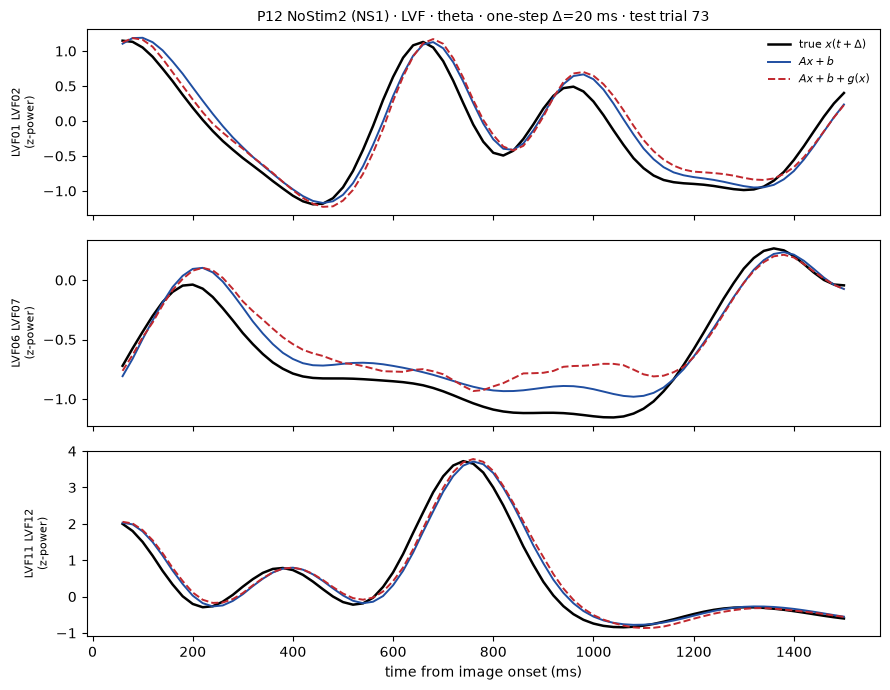

In [13]:
# ---------- POC part 2: horizon mini-sweep + trajectory figure ----------
# NOTE: with a 20-ms token stride, only multiples of 20 ms are realizable
# (spec's 10/50 ms horizons are not on the token grid; recorded as a deviation).
poc_horizons = [20, 40, 100, 200]
rows = []
models_at_h = {}
for h_ms in poc_horizons:
    hs = h_ms // TOKEN_STRIDE_MS
    Xtr_h, Ytr_h = make_pairs(z_r[tr], hs)
    Xva_h, Yva_h = make_pairs(z_r[va], hs)
    Xte_h, Yte_h = make_pairs(z_r[te], hs)
    A_h, b_h, lam_h = fit_ridge(Xtr_h, Ytr_h, Xva_h, Yva_h)
    R_tr = Ytr_h - ridge_predict(A_h, b_h, Xtr_h)
    R_va = Yva_h - ridge_predict(A_h, b_h, Xva_h)
    g_h = fit_residual_mlp(Xtr_h, R_tr, Xva_h, R_va)
    p_lin = ridge_predict(A_h, b_h, Xte_h)
    p_res = p_lin + mlp_predict(g_h, Xte_h)
    models_at_h[h_ms] = (A_h, b_h, g_h)
    for name, p in [("persistence", Xte_h), ("Ax+b", p_lin), ("Ax+b+g(x)", p_res)]:
        rows.append({"horizon_ms": h_ms, "model": name, **eval_all(Yte_h, p)})

poc_sweep = pd.DataFrame(rows)
display(poc_sweep.pivot(index="horizon_ms", columns="model", values="R2").round(4))

# ---------- Trajectory figure: one test trial, Δ=20 ms one-step predictions ----------
hs = 1
trial = te[0]
Xp, Yp = z_r[trial, :-hs, :], z_r[trial, hs:, :]
A20, b20, g20 = models_at_h[20]
p_lin = ridge_predict(A20, b20, Xp)
p_res = p_lin + mlp_predict(g20, Xp)
t_pred = token_t[hs:]

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, ch in zip(axes, [0, 5, 10]):
    ax.plot(t_pred, Yp[:, ch], color=COLOR_TRUE, lw=1.8, label="true $x(t+\\Delta)$")
    ax.plot(t_pred, p_lin[:, ch], color=COLOR_LINEAR, lw=1.4, label="$Ax+b$")
    ax.plot(t_pred, p_res[:, ch], color=COLOR_RESIDUAL, lw=1.4, ls="--", label="$Ax+b+g(x)$")
    ax.set_ylabel(f"{ch_tbl.loc[clean_idx[region_mask_in_clean], 'pair_name'].iloc[ch]}\n(z-power)", fontsize=8)
axes[0].legend(loc="upper right", fontsize=8, frameon=False)
axes[0].set_title(f"P12 NoStim2 (NS1) · {POC_LEAD} · theta · one-step Δ=20 ms · test trial {trial}", fontsize=10)
axes[-1].set_xlabel("time from image onset (ms)")
fig.tight_layout()
fig.savefig(FIG_DIR / "poc_trajectory_P12_LVF_theta.png", dpi=200)
plt.show()


In [16]:
# ---------- POC part 3: OOD (NS1-ID vs NS2-OOD, frozen model; spec §9-10 adapted) ----------
# NS2 = non-stimulated trials inside the Stim1 session (TrialDet 'Stimulation' == 0).
# Everything is FROZEN from NS1 training: normalization stats, A, b, lambda, g(x).
stim1_path = HERE / "BIPOLFieldTripFormat_AlignedToImagePresent_P12_Stim1.mat"
stim1_cache = CACHE_DIR / "P12_Stim1.npz"

if stim1_cache.exists() or stim1_path.exists():
    try:
        if stim1_cache.exists():
            sess_stim = load_cached("P12_Stim1")
        else:
            sess_stim = load_session(stim1_path)
            cache_session(sess_stim, "P12_Stim1")
    except OSError as e:
        sess_stim = None
        print(f"Stim1 file still uploading/truncated - rerun later. ({e})")
else:
    sess_stim = None
    print("Stim1 file not available yet - run this cell once the upload completes.")

if sess_stim is not None:
    # channel montage must be identical across sessions of the same patient
    assert (sess_stim["channels"]["pair_name"].to_numpy()
            == sess["channels"]["pair_name"].to_numpy()).all(), "channel mismatch across sessions"

    ns2_mask = sess_stim["trials"]["Stimulation"].to_numpy() == 0
    print(f"Stim1 session: {len(sess_stim['trials'])} trials, NS2 (non-stimulated) = {ns2_mask.sum()}")

    # identical preprocessing; SAME clean-channel set and NS1-train normalization stats
    pw_ood = band_power(sess_stim["data"][ns2_mask][:, clean_idx, :], sess_stim["fs"], PRIMARY_BAND)
    tok_ood, base_ood, _ = tokenize(pw_ood, sess_stim["time"])
    tok_ood_r = tok_ood[:, :, region_mask_in_clean]
    # frozen transform: reuse NS1 TRAINING baseline mean/sd (not NS2's own baseline)
    mu = base_r[tr].mean(axis=0); sd = base_r[tr].std(axis=0) + 1e-12
    z_ood = (tok_ood_r - mu[None, None, :]) / sd[None, None, :]

    h = PRIMARY_HORIZON_MS // TOKEN_STRIDE_MS
    Xood, Yood = make_pairs(z_ood, h)
    pred_lin_ood = ridge_predict(A, b, Xood)
    pred_res_ood = pred_lin_ood + mlp_predict(g, Xood)

    poc_ood = pd.DataFrame({name: eval_all(Yood, p)
                            for name, p in [("persistence", Xood),
                                            ("Ax+b", pred_lin_ood),
                                            ("Ax+b+g(x)", pred_res_ood)]}).T
    print("\nOOD (NS2 trials, frozen NS1 model):")
    display(poc_ood.round(4))

    cmp = pd.concat({"ID (NS1 test)": poc_id["R2"], "OOD (NS2)": poc_ood["R2"]}, axis=1)
    cmp["delta_R2"] = cmp["OOD (NS2)"] - cmp["ID (NS1 test)"]
    print("\nID vs OOD (R^2, frozen model):")
    display(cmp.round(4))


Stim1 file still uploading/truncated - rerun later. (Unable to synchronously open file (truncated file: eof = 1846541824, sblock->base_addr = 512, stored_eof = 2717009456))


In [17]:
# ---------- POC part 4: conflict-shift OOD (panel-C design; runs on NoStim2 alone) ----------
# Behavioral context shift: train/ID on LOW-conflict trials, test OOD on HIGH-conflict
# trials with the SAME frozen model (A, b, lambda, g and normalization stats).
conf = sess["trials"]["Conflict"].to_numpy()
print("Conflict levels:", {int(k): int(v) for k, v in zip(*np.unique(conf, return_counts=True))})
low_trials = np.flatnonzero(conf <= 1)     # congruent / low interference
high_trials = np.flatnonzero(conf >= 2)    # high interference
print(f"low-conflict trials: {len(low_trials)}, high-conflict trials: {len(high_trials)}")

# split LOW-conflict trials 60/20/20; HIGH-conflict is entirely held out (OOD)
tr_lo, va_lo, te_lo = trial_split(len(low_trials))
tr_lo, va_lo, te_lo = low_trials[tr_lo], low_trials[va_lo], low_trials[te_lo]

# frozen normalization from LOW-conflict TRAINING baselines
mu_lo = base_r[tr_lo].mean(axis=0); sd_lo = base_r[tr_lo].std(axis=0) + 1e-12
z_c = (tok_r - mu_lo[None, None, :]) / sd_lo[None, None, :]

h = PRIMARY_HORIZON_MS // TOKEN_STRIDE_MS
Xtr_c, Ytr_c = make_pairs(z_c[tr_lo], h)
Xva_c, Yva_c = make_pairs(z_c[va_lo], h)
Xid_c, Yid_c = make_pairs(z_c[te_lo], h)          # ID test: held-out low conflict
Xod_c, Yod_c = make_pairs(z_c[high_trials], h)    # OOD test: high conflict

A_c, b_c, lam_c = fit_ridge(Xtr_c, Ytr_c, Xva_c, Yva_c)
R_tr_c = Ytr_c - ridge_predict(A_c, b_c, Xtr_c)
R_va_c = Yva_c - ridge_predict(A_c, b_c, Xva_c)
g_c = fit_residual_mlp(Xtr_c, R_tr_c, Xva_c, R_va_c)

res = {}
for split, (Xs, Ys) in [("ID (low conflict)", (Xid_c, Yid_c)),
                        ("OOD (high conflict)", (Xod_c, Yod_c))]:
    p_l = ridge_predict(A_c, b_c, Xs)
    p_r = p_l + mlp_predict(g_c, Xs)
    res[split] = {"persistence": pop_r2(Ys, Xs), "Ax+b": pop_r2(Ys, p_l), "Ax+b+g(x)": pop_r2(Ys, p_r)}

conflict_ood = pd.DataFrame(res)
conflict_ood["delta_R2"] = conflict_ood["OOD (high conflict)"] - conflict_ood["ID (low conflict)"]
print(f"\nConflict-shift OOD (Δ={PRIMARY_HORIZON_MS} ms, frozen low-conflict model, R^2):")
display(conflict_ood.round(4))


Conflict levels: {0: 32, 1: 32, 2: 32, 3: 31}
low-conflict trials: 64, high-conflict trials: 63

Conflict-shift OOD (Δ=20 ms, frozen low-conflict model, R^2):


,ID (low conflict),OOD (high conflict),delta_R2
persistence,0.9819,0.9809,-0.0010
Ax+b,0.9774,0.9794,0.0020
Ax+b+g(x),0.9760,0.9769,0.0008


In [18]:
# ---------- Conflict-shift OOD across horizons (where dynamics matter) ----------
rows_c = []
for h_ms in [20, 40, 100, 200]:
    hs = h_ms // TOKEN_STRIDE_MS
    Xt, Yt = make_pairs(z_c[tr_lo], hs)
    Xv, Yv = make_pairs(z_c[va_lo], hs)
    Xi, Yi = make_pairs(z_c[te_lo], hs)
    Xo, Yo = make_pairs(z_c[high_trials], hs)
    A_hc, b_hc, _ = fit_ridge(Xt, Yt, Xv, Yv)
    g_hc = fit_residual_mlp(Xt, Yt - ridge_predict(A_hc, b_hc, Xt),
                            Xv, Yv - ridge_predict(A_hc, b_hc, Xv))
    for split, Xs, Ys in [("ID", Xi, Yi), ("OOD", Xo, Yo)]:
        p_l = ridge_predict(A_hc, b_hc, Xs)
        rows_c += [{"horizon_ms": h_ms, "split": split, "model": "persistence", "R2": pop_r2(Ys, Xs)},
                   {"horizon_ms": h_ms, "split": split, "model": "Ax+b", "R2": pop_r2(Ys, p_l)},
                   {"horizon_ms": h_ms, "split": split, "model": "Ax+b+g(x)",
                    "R2": pop_r2(Ys, p_l + mlp_predict(g_hc, Xs))}]

cs = pd.DataFrame(rows_c).pivot(index=["model", "horizon_ms"], columns="split", values="R2")
cs["delta_R2"] = cs["OOD"] - cs["ID"]
print("Conflict-shift OOD across horizons (frozen low-conflict model, R^2):")
display(cs.round(4))


Conflict-shift OOD across horizons (frozen low-conflict model, R^2):


split                       ID     OOD  delta_R2
model       horizon_ms                          
Ax+b        20          0.9774  0.9794    0.0020
            40          0.9123  0.9207    0.0085
            100         0.5504  0.6063    0.0559
            200         0.0129  0.1244    0.1116
Ax+b+g(x)   20          0.9760  0.9769    0.0008
            40          0.9101  0.9159    0.0058
            100         0.5449  0.6026    0.0576
            200        -0.0093  0.1212    0.1305
persistence 20          0.9819  0.9809   -0.0010
            40          0.9287  0.9260   -0.0027
            100         0.6010  0.6013    0.0003
            200        -0.1337 -0.0905    0.0432

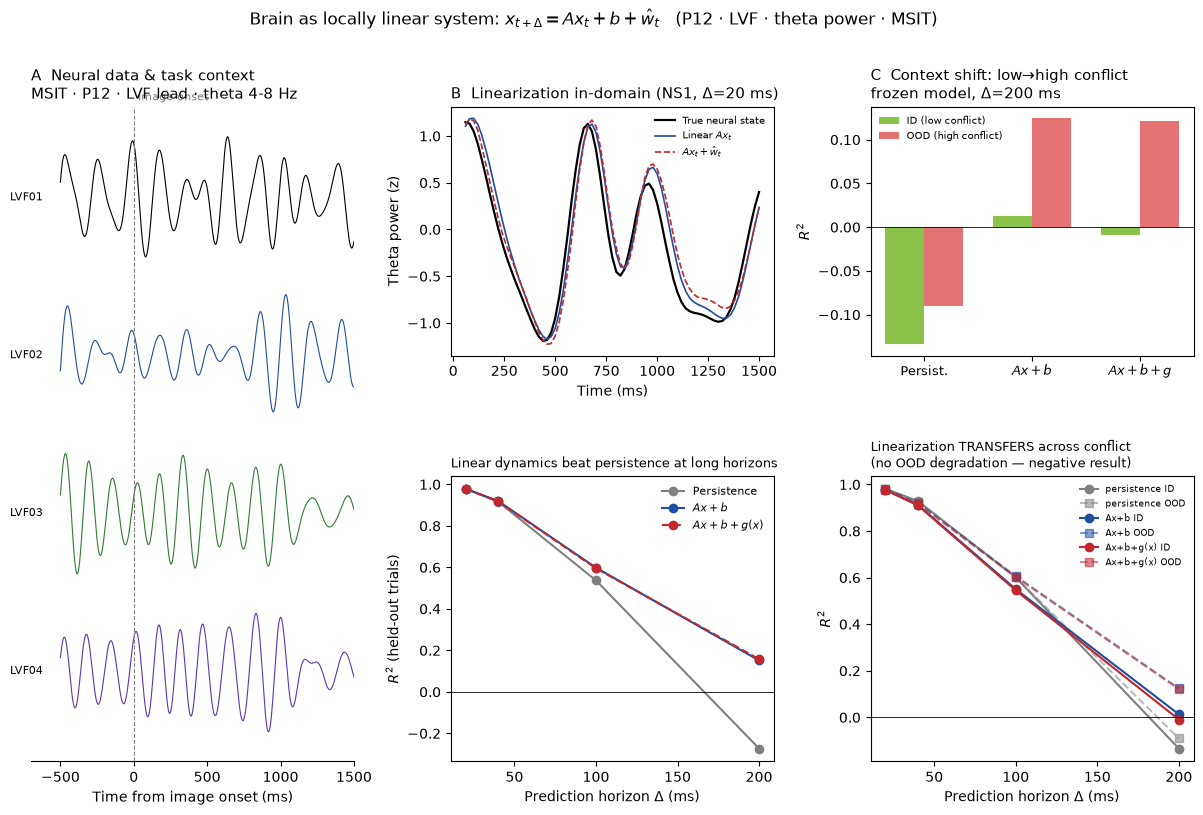

saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/main_figure_P12_LVF_theta.png


In [19]:
# ---------- MAIN FIGURE: A data/task context, B linearization in-domain, C context shift ----------
from matplotlib import gridspec
from scipy.signal import butter as _butter, sosfiltfilt as _sosfiltfilt

fig = plt.figure(figsize=(15, 8.5))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1.15], hspace=0.45, wspace=0.3)

# ===== Panel A: example theta-band traces (4 LVF channels, one NS1 trial) =====
axA = fig.add_subplot(gs[:, 0])
lvf_global = clean_idx[region_mask_in_clean]
demo_trial = int(te[0])
sos_t = _butter(4, BANDS[PRIMARY_BAND], btype="bandpass", fs=sess["fs"], output="sos")
t_ms_full = sess["time"] * 1000.0
show_m = (t_ms_full >= -500) & (t_ms_full <= 1500)
offset = 0.0
trace_colors = ["black", "#1f4ea1", "#2e7d32", "#5e35b1"]
for k, chg in enumerate(lvf_global[:4]):
    sig = _sosfiltfilt(sos_t, sess["data"][demo_trial, chg, :])[show_m]
    sig = sig / (np.abs(sig).max() + 1e-12)
    axA.plot(t_ms_full[show_m], sig + offset, lw=0.8, color=trace_colors[k])
    axA.text(-620, offset, sess["channels"]["pair_name"].iloc[chg].split()[0],
             ha="right", va="center", fontsize=8)
    offset -= 2.6
axA.axvline(0, color="gray", ls="--", lw=0.8)
axA.text(30, 1.6, "image onset", fontsize=8, color="gray")
axA.set_xlim(-700, 1500); axA.set_yticks([])
axA.set_xlabel("Time from image onset (ms)")
axA.set_title("A  Neural data & task context\nMSIT · P12 · %s lead · theta 4-8 Hz" % POC_LEAD,
              loc="left", fontsize=11)
for s in ("left", "right", "top"):
    axA.spines[s].set_visible(False)

# ===== Panel B (top): example one-step prediction, Δ=20 ms =====
axB1 = fig.add_subplot(gs[0, 1])
hs1 = 1
Xd, Yd = z_r[demo_trial, :-hs1, :], z_r[demo_trial, hs1:, :]
A20, b20, g20 = models_at_h[20]
pl = ridge_predict(A20, b20, Xd)
pr = pl + mlp_predict(g20, Xd)
ch_show = 0
tp = token_t[hs1:]
axB1.plot(tp, Yd[:, ch_show], color="black", lw=1.6, label="True neural state")
axB1.plot(tp, pl[:, ch_show], color="#1f4ea1", lw=1.2, label=r"Linear $Ax_t$")
axB1.plot(tp, pr[:, ch_show], color="#c1272d", lw=1.2, ls="--", label=r"$Ax_t+\hat{w}_t$")
axB1.set_xlabel("Time (ms)"); axB1.set_ylabel("Theta power (z)")
axB1.legend(fontsize=7, loc="upper right", frameon=False)
axB1.set_title("B  Linearization in-domain (NS1, $\\Delta$=20 ms)", loc="left", fontsize=11)

# ===== Panel B (bottom): horizon curves, ID =====
axB2 = fig.add_subplot(gs[1, 1])
piv = poc_sweep.pivot(index="horizon_ms", columns="model", values="R2")
axB2.plot(piv.index, piv["persistence"], "o-", color="gray", label="Persistence")
axB2.plot(piv.index, piv["Ax+b"], "o-", color="#1f4ea1", label=r"$Ax+b$")
axB2.plot(piv.index, piv["Ax+b+g(x)"], "o--", color="#c1272d", label=r"$Ax+b+g(x)$")
axB2.axhline(0, color="k", lw=0.6)
axB2.set_xlabel("Prediction horizon $\\Delta$ (ms)"); axB2.set_ylabel("$R^2$ (held-out trials)")
axB2.legend(fontsize=8, frameon=False)
axB2.set_title("Linear dynamics beat persistence at long horizons", fontsize=9, loc="left")

# ===== Panel C (top): conflict-shift bars at Δ=200 ms =====
axC1 = fig.add_subplot(gs[0, 2])
h_show = 200
sub = cs.reset_index()
sub = sub[sub["horizon_ms"] == h_show].set_index("model").reindex(["persistence", "Ax+b", "Ax+b+g(x)"])
x = np.arange(len(sub)); w = 0.36
axC1.bar(x - w/2, sub["ID"], w, color="#8bc34a", label="ID (low conflict)")
axC1.bar(x + w/2, sub["OOD"], w, color="#e57373", label="OOD (high conflict)")
axC1.axhline(0, color="k", lw=0.6)
axC1.set_xticks(x); axC1.set_xticklabels(["Persist.", "$Ax+b$", "$Ax+b+g$"], fontsize=9)
axC1.set_ylabel("$R^2$")
axC1.legend(fontsize=7, frameon=False)
axC1.set_title(f"C  Context shift: low→high conflict\nfrozen model, $\\Delta$={h_show} ms", loc="left", fontsize=11)

# ===== Panel C (bottom): ID vs OOD horizon curves for Ax+b =====
axC2 = fig.add_subplot(gs[1, 2])
for model, colr in [("persistence", "gray"), ("Ax+b", "#1f4ea1"), ("Ax+b+g(x)", "#c1272d")]:
    mrows = cs.loc[model]
    axC2.plot(mrows.index, mrows["ID"], "o-", color=colr, label=f"{model} ID")
    axC2.plot(mrows.index, mrows["OOD"], "s--", color=colr, alpha=0.55, label=f"{model} OOD")
axC2.axhline(0, color="k", lw=0.6)
axC2.set_xlabel("Prediction horizon $\\Delta$ (ms)"); axC2.set_ylabel("$R^2$")
axC2.legend(fontsize=6.5, frameon=False, ncol=1)
axC2.set_title("Linearization TRANSFERS across conflict\n(no OOD degradation — negative result)",
               fontsize=9, loc="left")

fig.suptitle("Brain as locally linear system: $x_{t+\\Delta} = Ax_t + b + \\hat{w}_t$   "
             "(P12 · LVF · theta power · MSIT)", fontsize=12, y=0.995)
out = FIG_DIR / "main_figure_P12_LVF_theta.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
fig.savefig(out.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
print("saved ->", out)


In [20]:
# ---------- RAW-SIGNAL VERSION: state = broadband LFP voltage (no band filtering) ----------
# Same tokenization (causal 40-ms mean, 20-ms stride), same models, same splits.
# Normalization: z-score per channel using TRAINING-trial baseline (-500..0 ms) stats.

# 1) tokens from raw voltage on the same LVF clean channels
raw = sess["data"][:, clean_idx, :][:, region_mask_in_clean, :]     # (trials, ch, samples)
tok_raw, base_raw_mean, _ = tokenize(raw, sess["time"])             # baseline mean unused for sd
t_ms_full = sess["time"] * 1000.0
base_m = (t_ms_full >= EPOCH_MS[0]) & (t_ms_full < 0)
base_sd_trial = raw[:, :, base_m].std(axis=-1)                      # (trials, ch)

mu_raw = tok_raw[tr][:, :, :].reshape(-1, tok_raw.shape[-1]).mean(axis=0)
sd_raw = base_sd_trial[tr].mean(axis=0) + 1e-12                     # train baseline sd
z_raw = (tok_raw - mu_raw[None, None, :]) / sd_raw[None, None, :]

# 2) fit across horizons (same 60/20/20 trial split tr/va/te as theta analysis)
rows_raw = []
models_raw = {}
for h_ms in [20, 40, 100, 200]:
    hsr = h_ms // TOKEN_STRIDE_MS
    Xt_, Yt_ = make_pairs(z_raw[tr], hsr)
    Xv_, Yv_ = make_pairs(z_raw[va], hsr)
    Xe_, Ye_ = make_pairs(z_raw[te], hsr)
    A_r, b_r, lam_r = fit_ridge(Xt_, Yt_, Xv_, Yv_)
    g_r = fit_residual_mlp(Xt_, Yt_ - ridge_predict(A_r, b_r, Xt_),
                           Xv_, Yv_ - ridge_predict(A_r, b_r, Xv_))
    models_raw[h_ms] = (A_r, b_r, g_r)
    p_l = ridge_predict(A_r, b_r, Xe_)
    p_r = p_l + mlp_predict(g_r, Xe_)
    for nm, pp in [("persistence", Xe_), ("Ax+b", p_l), ("Ax+b+g(x)", p_r)]:
        rows_raw.append({"horizon_ms": h_ms, "model": nm, "R2": pop_r2(Ye_, pp)})
raw_sweep = pd.DataFrame(rows_raw)
print("RAW signal, ID horizon sweep (R^2):")
display(raw_sweep.pivot(index="horizon_ms", columns="model", values="R2").round(4))

# 3) conflict-shift OOD with raw state (frozen low-conflict model)
mu_raw_lo = tok_raw[tr_lo].reshape(-1, tok_raw.shape[-1]).mean(axis=0)
sd_raw_lo = base_sd_trial[tr_lo].mean(axis=0) + 1e-12
z_raw_c = (tok_raw - mu_raw_lo[None, None, :]) / sd_raw_lo[None, None, :]
rows_raw_c = []
for h_ms in [20, 40, 100, 200]:
    hsr = h_ms // TOKEN_STRIDE_MS
    Xt_, Yt_ = make_pairs(z_raw_c[tr_lo], hsr)
    Xv_, Yv_ = make_pairs(z_raw_c[va_lo], hsr)
    Xi_, Yi_ = make_pairs(z_raw_c[te_lo], hsr)
    Xo_, Yo_ = make_pairs(z_raw_c[high_trials], hsr)
    A_rc, b_rc, _ = fit_ridge(Xt_, Yt_, Xv_, Yv_)
    g_rc = fit_residual_mlp(Xt_, Yt_ - ridge_predict(A_rc, b_rc, Xt_),
                            Xv_, Yv_ - ridge_predict(A_rc, b_rc, Xv_))
    for split, Xs_, Ys_ in [("ID", Xi_, Yi_), ("OOD", Xo_, Yo_)]:
        p_l = ridge_predict(A_rc, b_rc, Xs_)
        rows_raw_c += [{"horizon_ms": h_ms, "split": split, "model": "persistence", "R2": pop_r2(Ys_, Xs_)},
                       {"horizon_ms": h_ms, "split": split, "model": "Ax+b", "R2": pop_r2(Ys_, p_l)},
                       {"horizon_ms": h_ms, "split": split, "model": "Ax+b+g(x)",
                        "R2": pop_r2(Ys_, p_l + mlp_predict(g_rc, Xs_))}]
cs_raw = pd.DataFrame(rows_raw_c).pivot(index=["model", "horizon_ms"], columns="split", values="R2")
cs_raw["delta_R2"] = cs_raw["OOD"] - cs_raw["ID"]
print("\nRAW signal, conflict-shift OOD (frozen low-conflict model, R^2):")
display(cs_raw.round(4))


RAW signal, ID horizon sweep (R^2):


model,Ax+b,Ax+b+g(x),persistence
horizon_ms,,,
20,0.6923,0.6948,0.6053
40,0.3137,0.3197,-0.1692
100,0.1219,0.1230,-1.0847
200,0.0496,0.0586,-0.8183



RAW signal, conflict-shift OOD (frozen low-conflict model, R^2):


split                       ID     OOD  delta_R2
model       horizon_ms                          
Ax+b        20          0.7053  0.6550   -0.0503
            40          0.3232  0.2642   -0.0590
            100         0.0954  0.1258    0.0304
            200         0.0395  0.0528    0.0134
Ax+b+g(x)   20          0.7054  0.6546   -0.0508
            40          0.3233  0.2627   -0.0606
            100         0.0923  0.1239    0.0317
            200         0.0472  0.0506    0.0034
persistence 20          0.6220  0.5545   -0.0675
            40         -0.1360 -0.3263   -0.1904
            100        -1.0657 -1.2365   -0.1708
            200        -0.8687 -0.8115    0.0573

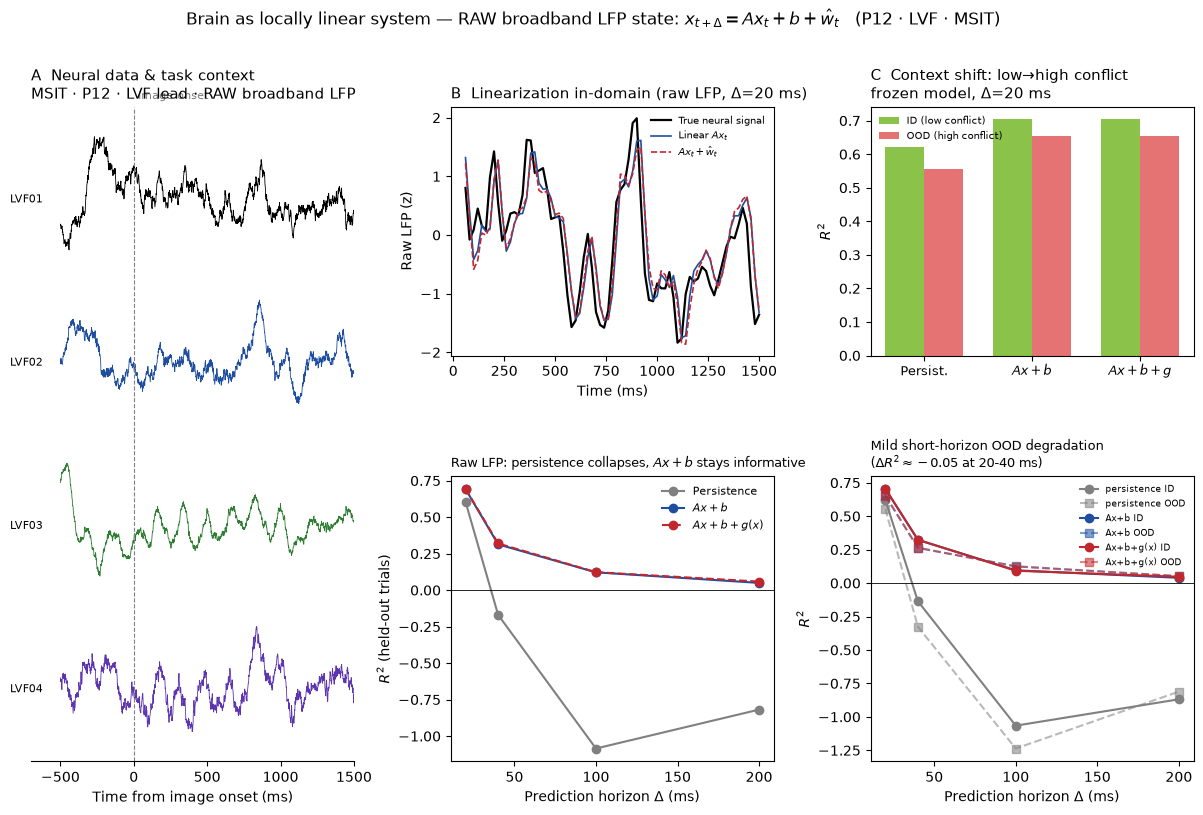

saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/main_figure_raw_P12_LVF.png


In [21]:
# ---------- RAW-SIGNAL MAIN FIGURE (mirror of the theta figure) ----------
fig = plt.figure(figsize=(15, 8.5))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1.15], hspace=0.45, wspace=0.3)

# ===== Panel A: raw broadband traces (4 LVF channels, one held-out trial) =====
axA = fig.add_subplot(gs[:, 0])
show_m = (t_ms_full >= -500) & (t_ms_full <= 1500)
offset = 0.0
for k, chg in enumerate(lvf_global[:4]):
    sig = sess["data"][demo_trial, chg, :][show_m]
    sig = sig / (np.abs(sig).max() + 1e-12)
    axA.plot(t_ms_full[show_m], sig + offset, lw=0.6, color=trace_colors[k])
    axA.text(-620, offset, sess["channels"]["pair_name"].iloc[chg].split()[0],
             ha="right", va="center", fontsize=8)
    offset -= 2.6
axA.axvline(0, color="gray", ls="--", lw=0.8)
axA.text(30, 1.6, "image onset", fontsize=8, color="gray")
axA.set_xlim(-700, 1500); axA.set_yticks([])
axA.set_xlabel("Time from image onset (ms)")
axA.set_title("A  Neural data & task context\nMSIT · P12 · %s lead · RAW broadband LFP" % POC_LEAD,
              loc="left", fontsize=11)
for s in ("left", "right", "top"):
    axA.spines[s].set_visible(False)

# ===== Panel B (top): example one-step prediction on raw state, Δ=20 ms =====
axB1 = fig.add_subplot(gs[0, 1])
hs1 = 1
Xd_r, Yd_r = z_raw[demo_trial, :-hs1, :], z_raw[demo_trial, hs1:, :]
A_r20, b_r20, g_r20 = models_raw[20]
pl_r = ridge_predict(A_r20, b_r20, Xd_r)
pr_r = pl_r + mlp_predict(g_r20, Xd_r)
tp = token_t[hs1:]
axB1.plot(tp, Yd_r[:, 0], color="black", lw=1.6, label="True neural signal")
axB1.plot(tp, pl_r[:, 0], color="#1f4ea1", lw=1.2, label=r"Linear $Ax_t$")
axB1.plot(tp, pr_r[:, 0], color="#c1272d", lw=1.2, ls="--", label=r"$Ax_t+\hat{w}_t$")
axB1.set_xlabel("Time (ms)"); axB1.set_ylabel("Raw LFP (z)")
axB1.legend(fontsize=7, loc="upper right", frameon=False)
axB1.set_title("B  Linearization in-domain (raw LFP, $\\Delta$=20 ms)", loc="left", fontsize=11)

# ===== Panel B (bottom): horizon curves, ID =====
axB2 = fig.add_subplot(gs[1, 1])
piv_r = raw_sweep.pivot(index="horizon_ms", columns="model", values="R2")
axB2.plot(piv_r.index, piv_r["persistence"], "o-", color="gray", label="Persistence")
axB2.plot(piv_r.index, piv_r["Ax+b"], "o-", color="#1f4ea1", label=r"$Ax+b$")
axB2.plot(piv_r.index, piv_r["Ax+b+g(x)"], "o--", color="#c1272d", label=r"$Ax+b+g(x)$")
axB2.axhline(0, color="k", lw=0.6)
axB2.set_xlabel("Prediction horizon $\\Delta$ (ms)"); axB2.set_ylabel("$R^2$ (held-out trials)")
axB2.legend(fontsize=8, frameon=False)
axB2.set_title("Raw LFP: persistence collapses, $Ax+b$ stays informative", fontsize=9, loc="left")

# ===== Panel C (top): conflict-shift bars at Δ=20 ms (raw) =====
axC1 = fig.add_subplot(gs[0, 2])
h_show = 20
sub_r = cs_raw.reset_index()
sub_r = sub_r[sub_r["horizon_ms"] == h_show].set_index("model").reindex(["persistence", "Ax+b", "Ax+b+g(x)"])
x = np.arange(len(sub_r)); w = 0.36
axC1.bar(x - w/2, sub_r["ID"], w, color="#8bc34a", label="ID (low conflict)")
axC1.bar(x + w/2, sub_r["OOD"], w, color="#e57373", label="OOD (high conflict)")
axC1.axhline(0, color="k", lw=0.6)
axC1.set_xticks(x); axC1.set_xticklabels(["Persist.", "$Ax+b$", "$Ax+b+g$"], fontsize=9)
axC1.set_ylabel("$R^2$")
axC1.legend(fontsize=7, frameon=False)
axC1.set_title(f"C  Context shift: low→high conflict\nfrozen model, $\\Delta$={h_show} ms", loc="left", fontsize=11)

# ===== Panel C (bottom): ID vs OOD horizon curves (raw) =====
axC2 = fig.add_subplot(gs[1, 2])
for model, colr in [("persistence", "gray"), ("Ax+b", "#1f4ea1"), ("Ax+b+g(x)", "#c1272d")]:
    mrows = cs_raw.loc[model]
    axC2.plot(mrows.index, mrows["ID"], "o-", color=colr, label=f"{model} ID")
    axC2.plot(mrows.index, mrows["OOD"], "s--", color=colr, alpha=0.55, label=f"{model} OOD")
axC2.axhline(0, color="k", lw=0.6)
axC2.set_xlabel("Prediction horizon $\\Delta$ (ms)"); axC2.set_ylabel("$R^2$")
axC2.legend(fontsize=6.5, frameon=False)
axC2.set_title("Mild short-horizon OOD degradation\n($\\Delta R^2 \\approx -0.05$ at 20-40 ms)",
               fontsize=9, loc="left")

fig.suptitle("Brain as locally linear system — RAW broadband LFP state: "
             "$x_{t+\\Delta} = Ax_t + b + \\hat{w}_t$   (P12 · LVF · MSIT)", fontsize=12, y=0.995)
out = FIG_DIR / "main_figure_raw_P12_LVF.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
fig.savefig(out.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
print("saved ->", out)


## 5b. Where are the electrodes? — anatomy + model schematic

Glass-brain view of all 151 bipolar pairs (MNI midpoint coordinates from `ParcellationValues`), colored by coarse anatomical area, with ictal-onset pairs marked ✕. Right: the same recording drawn as an LLM-style linear token model.

saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/electrode_map_P12.png
         x     y     z   n  n_clean                            area
lead                                                               
LAF  -40.0  13.7  51.0  11        9         dorsolateral prefrontal
LAI  -31.5 -15.6  52.6  11       11                    sensorimotor
LAO  -34.9 -70.5  18.1  15        8               parieto-occipital
LMF  -30.2  -4.0  56.6  13        4  premotor / dorsomedial frontal
LOF  -35.0  21.1  24.5  13        0        ventrolateral prefrontal
LPF  -31.3 -18.8  62.3  13       13                    sensorimotor
LPO  -19.1 -93.4   7.3   9        8               parieto-occipital
LPT  -39.9 -52.4   0.3   8        5              posterior temporal
LVF  -24.6  -7.9  44.1  15       15  premotor / dorsomedial frontal
RAF   23.5  33.7  35.3  11       11        ventrolateral prefrontal
RAT   41.3   4.6   2.8   8        8         temporal / peri-insular
RMF   13.7  -6.

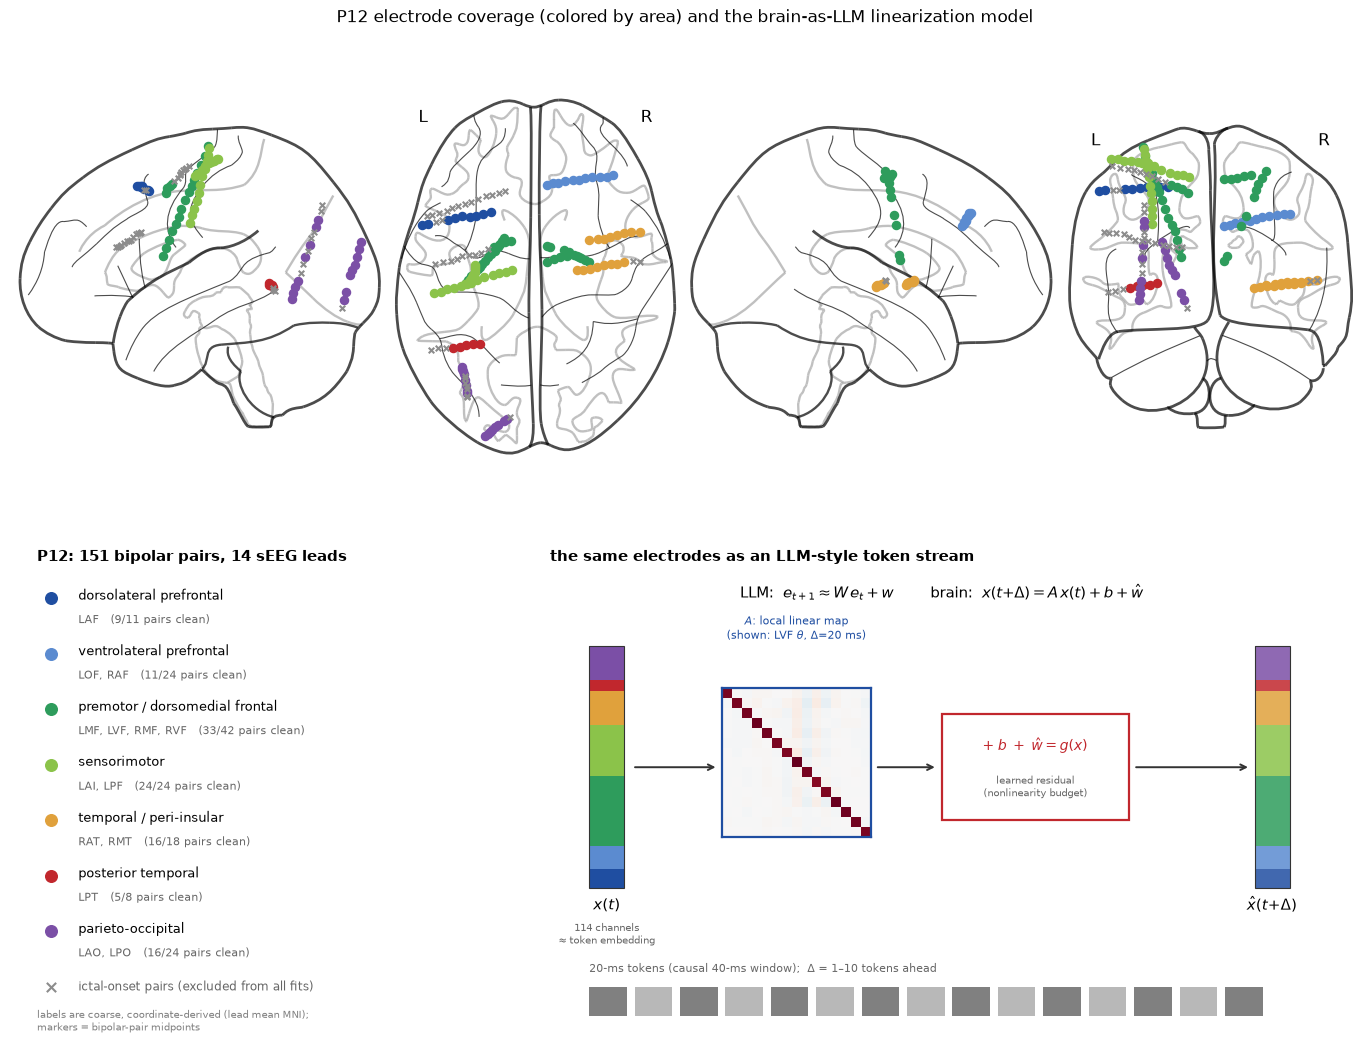

In [11]:
# --- Electrode anatomy (glass brain) + "brain as LLM" model schematic ---
from nilearn import plotting as niplot
from matplotlib.patches import Rectangle

chdf = sess["channels"].copy()
coords = chdf[["parc4", "parc5", "parc6"]].to_numpy(float)  # bipolar-pair midpoints, MNI mm
valid = np.isfinite(coords).all(axis=1)

def coarse_area(x, y, z):
    """Coarse, coordinate-derived anatomical label (from each lead's mean MNI position)."""
    if y <= -60:            return "parieto-occipital"
    if y <= -35 and z < 25: return "posterior temporal"
    if z < 20:              return "temporal / peri-insular"
    if z >= 40 and y >= 10: return "dorsolateral prefrontal"
    if y >= 10:             return "ventrolateral prefrontal"
    if y <= -12:            return "sensorimotor"
    return "premotor / dorsomedial frontal"

lead_stats = chdf[valid].groupby("lead").agg(
    x=("parc4", "mean"), y=("parc5", "mean"), z=("parc6", "mean"),
    n=("pair_name", "size"), n_clean=("ictal", lambda s: int((~s).sum())))
lead_area = {ld: coarse_area(r.x, r.y, r.z) for ld, r in lead_stats.iterrows()}
chdf["area"] = chdf["lead"].map(lead_area)

AREA_ORDER = ["dorsolateral prefrontal", "ventrolateral prefrontal", "premotor / dorsomedial frontal",
              "sensorimotor", "temporal / peri-insular", "posterior temporal", "parieto-occipital"]
AREA_COLORS = dict(zip(AREA_ORDER, ["#1f4ea1", "#5b8bd0", "#2e9c5c", "#8bc34a", "#e0a13c", "#c1272d", "#7b4fa6"]))

fig = plt.figure(figsize=(13.5, 10.5))
disp = niplot.plot_glass_brain(None, display_mode="lzry", figure=fig, axes=(0.0, 0.52, 1.0, 0.44))
for area in AREA_ORDER:
    m = (valid & (~chdf["ictal"]) & (chdf["area"] == area)).to_numpy()
    if m.any():
        disp.add_markers(coords[m], marker_color=AREA_COLORS[area], marker_size=34)
m_ict = (valid & chdf["ictal"]).to_numpy()
disp.add_markers(coords[m_ict], marker_color="0.55", marker_size=16, marker="x")

# ---- legend (bottom left) ----
ax_leg = fig.add_axes([0.02, 0.02, 0.34, 0.46]); ax_leg.axis("off")
ax_leg.text(0.0, 1.00, "P12: 151 bipolar pairs, 14 sEEG leads", fontsize=10.5, weight="bold",
            transform=ax_leg.transAxes, va="top")
yy = 0.90
for area in AREA_ORDER:
    lds = sorted(ld for ld, a in lead_area.items() if a == area)
    if not lds:
        continue
    n_cl = int(lead_stats.loc[lds, "n_clean"].sum()); n_tot = int(lead_stats.loc[lds, "n"].sum())
    ax_leg.scatter([0.03], [yy], s=70, color=AREA_COLORS[area], transform=ax_leg.transAxes, clip_on=False)
    ax_leg.text(0.09, yy + 0.005, area, fontsize=9.5, va="center", transform=ax_leg.transAxes)
    ax_leg.text(0.09, yy - 0.045, f"{', '.join(lds)}   ({n_cl}/{n_tot} pairs clean)",
                fontsize=8, color="0.4", va="center", transform=ax_leg.transAxes)
    yy -= 0.115
ax_leg.scatter([0.03], [yy], s=45, color="0.55", marker="x", transform=ax_leg.transAxes)
ax_leg.text(0.09, yy, "ictal-onset pairs (excluded from all fits)", fontsize=8.5, color="0.4",
            va="center", transform=ax_leg.transAxes)
ax_leg.text(0.0, yy - 0.09, "labels are coarse, coordinate-derived (lead mean MNI);\nmarkers = bipolar-pair midpoints",
            fontsize=7.5, color="0.5", transform=ax_leg.transAxes)

# ---- "brain as LLM" schematic (bottom right) ----
ax_s = fig.add_axes([0.40, 0.02, 0.58, 0.46]); ax_s.axis("off")
ax_s.set_xlim(0, 1); ax_s.set_ylim(0, 1)
ax_s.text(0.0, 1.00, "the same electrodes as an LLM-style token stream", fontsize=10.5, weight="bold", va="top")
ax_s.text(0.5, 0.90, "LLM:  $e_{t+1} \\approx W\\,e_t + w$        brain:  $x(t{+}\\Delta) = A\\,x(t) + b + \\hat{w}$",
          ha="center", fontsize=10.5)

clean_ch = chdf[~chdf["ictal"]].copy()
clean_ch["_o"] = clean_ch["area"].map({a: i for i, a in enumerate(AREA_ORDER)})
clean_ch = clean_ch.sort_values("_o")
n_cells = len(clean_ch)

def draw_vec(x0, alpha=1.0):
    h = 0.50 / n_cells
    for i, area in enumerate(clean_ch["area"]):
        ax_s.add_patch(Rectangle((x0, 0.30 + i * h), 0.045, h, color=AREA_COLORS[area], alpha=alpha, lw=0))
    ax_s.add_patch(Rectangle((x0, 0.30), 0.045, 0.50, fill=False, ec="0.2", lw=0.8))

draw_vec(0.05); draw_vec(0.90, alpha=0.85)
ax_s.text(0.0725, 0.255, "$x(t)$", ha="center", fontsize=11)
ax_s.text(0.9225, 0.255, "$\\hat{x}(t{+}\\Delta)$", ha="center", fontsize=11)
ax_s.text(0.0725, 0.185, "114 channels\n≈ token embedding", ha="center", fontsize=7.5, color="0.4")

axA = ax_s.inset_axes([0.22, 0.36, 0.19, 0.40])
vA = np.abs(A).max()
axA.imshow(A, cmap="RdBu_r", vmin=-vA, vmax=vA)
axA.set_xticks([]); axA.set_yticks([])
for sp in axA.spines.values():
    sp.set_color(COLOR_LINEAR); sp.set_linewidth(1.6)
ax_s.text(0.315, 0.815, "$A$: local linear map\n(shown: LVF $\\theta$, $\\Delta$=20 ms)",
          ha="center", fontsize=8, color=COLOR_LINEAR)

ax_s.add_patch(Rectangle((0.50, 0.44), 0.24, 0.22, fill=False, ec=COLOR_RESIDUAL, lw=1.6))
ax_s.text(0.62, 0.585, "$+\\;b\\;+\\;\\hat{w}=g(x)$", ha="center", fontsize=10, color=COLOR_RESIDUAL)
ax_s.text(0.62, 0.49, "learned residual\n(nonlinearity budget)", ha="center", fontsize=7.5, color="0.4")

for x0, x1 in [(0.105, 0.215), (0.415, 0.495), (0.745, 0.895)]:
    ax_s.annotate("", xy=(x1, 0.55), xytext=(x0, 0.55),
                  arrowprops=dict(arrowstyle="->", lw=1.4, color="0.2"))

for i in range(15):
    ax_s.add_patch(Rectangle((0.05 + i * 0.058, 0.035), 0.048, 0.06,
                             color="0.72" if i % 2 else "0.5", lw=0))
ax_s.text(0.05, 0.125, "20-ms tokens (causal 40-ms window);  $\\Delta$ = 1–10 tokens ahead",
          fontsize=8, color="0.4")

fig.suptitle("P12 electrode coverage (colored by area) and the brain-as-LLM linearization model",
             fontsize=12, y=0.995)
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"electrode_map_P12.{ext}", dpi=200, bbox_inches="tight")
print(f"saved -> {FIG_DIR / 'electrode_map_P12.png'}")
print(lead_stats.round(1).assign(area=[lead_area[ld] for ld in lead_stats.index]).to_string())
plt.show()

## 5c. Robustness: does the conclusion hold over *enough data*?

The POC above used one lead (LVF), one session (NoStim2), and a short window (0–1.5 s).
Here we re-run the identical pipeline on **both no-stim sessions combined**, an **extended 0–3.5 s token window**, and **every lead with ≥ 5 clean channels** — same whole-trial 60/20/20 split, same train-only λ / normalization rules.

In [17]:
# --- Robustness: every lead x BOTH no-stim sessions x extended 0-3.5 s window ---
# Addresses "only a short interval of the data": ~2.6x more trials (NS1+NS2),
# 2.3x longer token window, and all leads with >=5 clean channels (not just LVF).
NS1_PATH = HERE / "BIPOLFieldTripFormat_AlignedToImagePresent_P12_NoStim1.mat"
if (CACHE_DIR / "P12_NoStim1.npz").exists():
    sess1 = load_cached("P12_NoStim1")
else:
    sess1 = load_session(NS1_PATH)
    cache_session(sess1, "P12_NoStim1")
sess1["channels"]["lead"] = sess1["channels"]["pair_name"].str.extract(r"^([A-Za-z]+)")

# Montages differ slightly (NS1: 145 pairs / 45 ictal, NS2: 151 / 37).
# Keep only pairs present in BOTH sessions and clean in BOTH sessions.
c1, c2 = sess1["channels"], sess["channels"]
ict1 = dict(zip(c1["pair_name"], c1["ictal"]))
keep = [p for p, ict in zip(c2["pair_name"], c2["ictal"])
        if p in ict1 and not ict and not ict1[p]]
idx1 = pd.Index(c1["pair_name"]).get_indexer(keep)
idx2 = pd.Index(c2["pair_name"]).get_indexer(keep)
lead_of_keep = c2.set_index("pair_name").loc[keep, "lead"].to_numpy()
print(f"NoStim1: {sess1['data'].shape[0]} trials | NoStim2: {sess['data'].shape[0]} trials | "
      f"pairs clean in both sessions: {len(keep)}")

T_END_MS = 3500  # image onset .. +3.5 s (median RT ~1-1.5 s; trials recorded to +4 s)

def tokenize_upto(power, time, t_end_ms):
    """Same causal tokens as tokenize(), but out to t_end_ms."""
    t_ms = time * 1000.0
    token_t = np.arange(CAUSAL_WINDOW_MS, t_end_ms + 1, TOKEN_STRIDE_MS, dtype=float)
    toks = [power[:, :, (t_ms > t - CAUSAL_WINDOW_MS) & (t_ms <= t)].mean(axis=-1) for t in token_t]
    base_m = (t_ms >= EPOCH_MS[0]) & (t_ms < 0)
    return np.stack(toks, axis=1), power[:, :, base_m].mean(axis=-1), token_t

d1 = sess1["data"][:, idx1, :]
good1 = ~np.isnan(d1).any(axis=(1, 2))  # NS1 contains aborted trial(s) padded with NaN
if (~good1).any():
    print(f"dropping {(~good1).sum()} NS1 trial(s) with NaN data")
pw1 = band_power(d1[good1], sess1["fs"], PRIMARY_BAND)
tok1, base1, token_t_ext = tokenize_upto(pw1, sess1["time"], T_END_MS)
del pw1, d1
pw2 = band_power(sess["data"][:, idx2, :], sess["fs"], PRIMARY_BAND)
tok2, base2, _ = tokenize_upto(pw2, sess["time"], T_END_MS)
del pw2

tok_all = np.concatenate([tok1, tok2], axis=0)
base_all = np.concatenate([base1, base2], axis=0)
n_all = tok_all.shape[0]
tr_a, va_a, te_a = trial_split(n_all)
z_all = normalize_tokens(tok_all, base_all, tr_a)
print(f"combined: {n_all} trials x {tok_all.shape[1]} tokens (40..{T_END_MS} ms) x {tok_all.shape[2]} ch, "
      f"split {len(tr_a)}/{len(va_a)}/{len(te_a)}")

HORIZONS_EXT = [20, 100, 200]
MIN_CH = 5
rows = []
for lead in sorted(set(lead_of_keep)):
    cols = np.flatnonzero(lead_of_keep == lead)
    if len(cols) < MIN_CH:
        continue
    z_l = z_all[:, :, cols]
    for h_ms in HORIZONS_EXT:
        h = h_ms // TOKEN_STRIDE_MS
        Xtr_l, Ytr_l = make_pairs(z_l[tr_a], h)
        Xva_l, Yva_l = make_pairs(z_l[va_a], h)
        Xte_l, Yte_l = make_pairs(z_l[te_a], h)
        A_l, b_l, lam_l = fit_ridge(Xtr_l, Ytr_l, Xva_l, Yva_l)
        rows.append(dict(lead=lead, area=lead_area[lead], n_ch=len(cols), horizon_ms=h_ms, lam=lam_l,
                         R2_persistence=pop_r2(Yte_l, Xte_l),
                         R2_linear=pop_r2(Yte_l, ridge_predict(A_l, b_l, Xte_l))))

summary = pd.DataFrame(rows)
summary["delta_R2"] = summary["R2_linear"] - summary["R2_persistence"]
summary.to_csv(RESULTS_DIR / "robustness_all_leads_theta.csv", index=False)
display(summary.round(3))

NoStim1: 125 trials | NoStim2: 127 trials | pairs clean in both sessions: 97
dropping 1 NS1 trial(s) with NaN data
combined: 251 trials x 174 tokens (40..3500 ms) x 97 ch, split 151/50/50


,lead,area,n_ch,horizon_ms,lam,R2_persistence,R2_linear,delta_R2
0,LAF,dorsolateral prefrontal,9,20,100.000,0.977,0.975,-0.001
1,LAF,dorsolateral prefrontal,9,100,100.000,0.500,0.530,0.029
2,LAF,dorsolateral prefrontal,9,200,100.000,-0.328,0.085,0.413
3,LAI,sensorimotor,10,20,0.001,0.978,0.978,0.000
4,LAI,sensorimotor,10,100,0.001,0.521,0.579,0.058
5,LAI,sensorimotor,10,200,0.001,-0.251,0.146,0.396
6,LPF,sensorimotor,13,20,10.000,0.983,0.983,0.000
7,LPF,sensorimotor,13,100,100.000,0.625,0.669,0.044
8,LPF,sensorimotor,13,200,100.000,-0.042,0.259,0.301
9,LPO,parieto-occipital,6,20,10.000,0.977,0.978,0.001


/tmp/ipykernel_70060/3129553052.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()


saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/robustness_summary_P12_theta.png


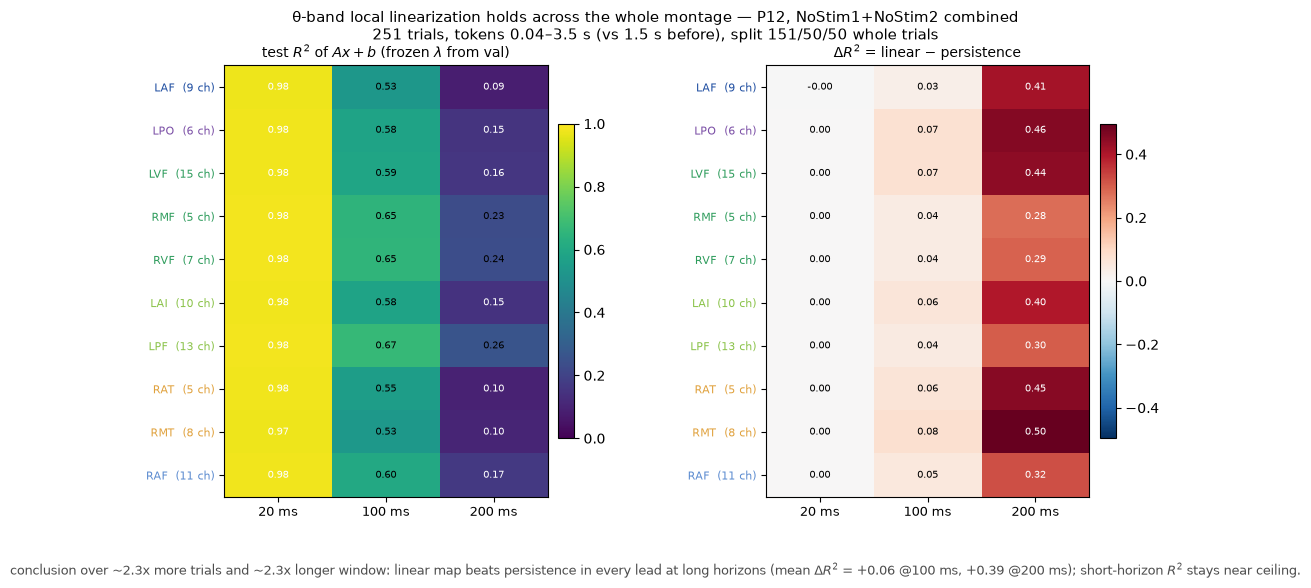

In [18]:
# --- Robustness figure: leads x horizons heatmaps ---
order = summary.sort_values(["area", "lead"]).drop_duplicates("lead")["lead"].tolist()
R2lin = summary.pivot(index="lead", columns="horizon_ms", values="R2_linear").loc[order]
R2per = summary.pivot(index="lead", columns="horizon_ms", values="R2_persistence").loc[order]
dR2 = R2lin - R2per
n_ch_of = summary.drop_duplicates("lead").set_index("lead")["n_ch"]
area_of = summary.drop_duplicates("lead").set_index("lead")["area"]

fig2, axes2 = plt.subplots(1, 2, figsize=(11.5, 5.6), gridspec_kw=dict(wspace=0.55))

def heat(ax, M, title, cmap, vmin, vmax):
    im = ax.imshow(M.to_numpy(), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(HORIZONS_EXT)), [f"{h} ms" for h in HORIZONS_EXT], fontsize=9)
    ax.set_yticks(range(len(order)), [f"{ld}  ({int(n_ch_of[ld])} ch)" for ld in order], fontsize=8)
    for lbl, ld in zip(ax.get_yticklabels(), order):
        lbl.set_color(AREA_COLORS[area_of[ld]])
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.iat[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if (v - vmin) / (vmax - vmin + 1e-12) > 0.75 or (v - vmin) / (vmax - vmin + 1e-12) < 0.2 else "black")
    ax.set_title(title, fontsize=10)
    fig2.colorbar(im, ax=ax, fraction=0.045, pad=0.03)

vlo = float(min(0.0, R2lin.to_numpy().min()))
heat(axes2[0], R2lin, "test $R^2$ of $Ax+b$ (frozen $\\lambda$ from val)", "viridis", vlo, 1.0)
dmax = float(np.abs(dR2.to_numpy()).max())
heat(axes2[1], dR2, "$\\Delta R^2$ = linear $-$ persistence", "RdBu_r", -dmax, dmax)

d100 = dR2[100].mean(); d200 = dR2[200].mean()
fig2.suptitle(
    f"θ-band local linearization holds across the whole montage — P12, NoStim1+NoStim2 combined\n"
    f"{n_all} trials, tokens 0.04–{T_END_MS/1000:.1f} s (vs 1.5 s before), split {len(tr_a)}/{len(va_a)}/{len(te_a)} whole trials",
    fontsize=10.5)
fig2.text(0.5, -0.03,
          f"conclusion over ~2.3x more trials and ~2.3x longer window: linear map beats persistence in every lead at long horizons "
          f"(mean $\\Delta R^2$ = +{d100:.2f} @100 ms, +{d200:.2f} @200 ms); short-horizon $R^2$ stays near ceiling.",
          ha="center", fontsize=9, color="0.3")
fig2.tight_layout()
for ext in ("png", "pdf"):
    fig2.savefig(FIG_DIR / f"robustness_summary_P12_theta.{ext}", dpi=200, bbox_inches="tight")
print(f"saved -> {FIG_DIR / 'robustness_summary_P12_theta.png'}")
plt.show()

## 6. Horizon sweep (STEP 7, Analysis 3)

Δ ∈ {10, 20, 50, 100, 200} ms × {persistence, $Ax$, $Ax+\hat{w}$} × patients → `results/horizon_metrics.csv`. No monotonicity forced.

In [16]:
print("NaN frac tok1:", np.isnan(tok1).mean(), " tok2:", np.isnan(tok2).mean())
d1 = sess1["data"][:, idx1, :]
nan_by_trial = np.isnan(d1).any(axis=(1, 2))
nan_by_ch = np.isnan(d1).any(axis=(0, 2))
print("NS1 trials with NaN:", nan_by_trial.sum(), "/", len(nan_by_trial))
print("NS1 channels with NaN:", nan_by_ch.sum(), "/", len(nan_by_ch))
# where in time?
tm = np.isnan(d1).any(axis=(0, 1))
if tm.any():
    print("NaN sample range:", np.flatnonzero(tm)[[0, -1]], "of", d1.shape[-1])

NaN frac tok1: 0.008  tok2: 0.0
NS1 trials with NaN: 1 / 125
NS1 channels with NaN: 97 / 97
NaN sample range: [   0 5999] of 6000


## 7. OOD: drug-state shift (STEPS 10-11, Analyses 4 + control)

Train placebo → frozen model → test held-out placebo (ID) vs scopolamine (OOD). Then the symmetric reverse (train scopolamine). Report $R^2_{ID} - R^2_{OOD}$ and residual-energy change → `results/ood_metrics.csv`.

In [ ]:
# TODO: OOD analysis (frozen model, both directions). Secondary: FR<->AR task transfer (spec §16).

## 8. Robustness & controls (STEPS 12, 14; spec §20)

Frequency bands (all 5) · temporal shuffle (should collapse) · trial shuffle (should strongly decrease) · electrode-count subsampling · patient-wise leave-one-out on the central claim.

In [ ]:
# TODO: shuffle controls + band robustness.

## 9. Cross-region "layer" mapping (STEP 13, Analysis 5)

Temporal cortex → entorhinal → hippocampus; lags δ ∈ {0, 10, 20, 50, 100} ms (selected on training data, all reported). Compare recurrent-only $R_l x^{(l+1)}_t$ vs source+recurrent $A_l x^{(l)}_t + R_l x^{(l+1)}_t$ → `results/layer_metrics.csv`.

In [ ]:
# TODO: cross-region models (only where simultaneous coverage exists; never fabricate layers).

## 10. Matrix diagnostics (spec §18)

Eigenvalue spectrum (complex plane), spectral radius, singular values, effective rank, condition number of each fitted $A$.

In [ ]:
# TODO: A-matrix diagnostics.

## 11. Patient-level statistics (STEP 15, spec §19)

One summary metric per patient per comparison → paired statistics across patients (linear vs linear+residual; ID vs OOD). Individual patient dots in all plots.

In [ ]:
# TODO: paired stats (Wilcoxon / paired t as appropriate).

## 12. Main four-panel figure (STEP 16, spec §22-24)

A: brain-as-network mapping · B: local linearization + representative real prediction (patient closest to median improvement — predefined, no cherry-picking) · C: horizon curves · D: OOD degradation. Colors: black = truth, blue = $Ax$, red = $Ax+\hat{w}$, identical across panels. Vector output.

In [ ]:
# TODO: figure assembly -> figures/main_figure.pdf/.png